## Step 1: Convert Shapefiles to PyPSA CSVs

In [3]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString
from pathlib import Path
import numpy as np

# Paths
input_lines = 'qgis/lines_aut.shp'
input_buses = 'qgis/buses_aut.shp'
output_dir = Path('pypsa_csv')
output_dir.mkdir(parents=True, exist_ok=True)

# Load shapefiles
gdf_lines = gpd.read_file(input_lines)
gdf_buses = gpd.read_file(input_buses)

## Debug lines
print("gdf_lines check for NAN: ", gdf_lines.geometry.isnull().sum().sum())

# Ensure proper CRS (should be EPSG:4326 for PyPSA)
gdf_lines = gdf_lines.to_crs(epsg=4326)
gdf_buses = gdf_buses.to_crs(epsg=4326)

# Process buses
bus_df = gdf_buses.copy()
bus_df['bus'] = [f'bus{i}' for i in range(len(bus_df))]
bus_df['x'] = bus_df.geometry.x
bus_df['y'] = bus_df.geometry.y
bus_df = bus_df[['bus', 'x', 'y']]
bus_df = bus_df.dropna(subset=['x', 'y'])
bus_df.to_csv(output_dir / 'buses.csv', index=False)

# Map geometries to bus ids
bus_index = bus_df.set_index(['x', 'y'])['bus'].to_dict()

# Process lines
line_rows = []
for idx, row in gdf_lines.iterrows():
    line: LineString = row.geometry
    if line is None or line.is_empty:
        continue
    coords = list(line.coords)
    if len(coords) < 2:
        continue
    x0, y0 = map(round, coords[0])
    x1, y1 = map(round, coords[-1])
    bus0 = bus_index.get((x0, y0))
    bus1 = bus_index.get((x1, y1))
    if not bus0 or not bus1 or bus0 == bus1:
        continue
    line_rows.append({
        'name': f'line{idx}',
        'bus0': bus0,
        'bus1': bus1,
        'length': line.length,
    })

line_df = pd.DataFrame(line_rows)
line_df.to_csv(output_dir / 'lines.csv', index=False)

gdf_lines check for NAN:  602


In [15]:
filtered_gdf_lines = gdf_lines[gdf_lines['geometry'].notnull()]
## Debug lines
print("gdf_lines check for NAN: ", filtered_gdf_lines.geometry.isnull().sum().sum())

gdf_lines check for NAN:  0


In [17]:
for idx, row in filtered_gdf_lines.iterrows():
    print(row['geometry'].simplify(simplify_tolerance, preserve_topology=True))

LINESTRING (13.035616599900289 48.220731508220304, 13.037520399904826 48.22033830821942, 13.057288099950748 48.229493308237814, 13.079954400002011 48.25541790829109)
LINESTRING (13.080251700002744 48.2550372082903, 13.057288099950748 48.229493308237814, 13.037520399904826 48.22033830821942, 13.035082699899043 48.22062370822013)
LINESTRING (13.036658199902739 48.2208891082206, 13.039567099909393 48.22337250822568, 13.03547819989893 48.23219490824428, 13.032406699891471 48.23435630824895, 13.032397099891105 48.23811110825678, 13.079611600001172 48.2556972082917)
LINESTRING (13.079611600001172 48.2556972082917, 13.03238109989106 48.23828520825716, 13.009170021602529 48.2435018216593)
LINESTRING (16.899789409980027 47.84484241093029, 16.886721709933376 47.84795901094291, 16.871904709880724 47.85909691098301, 16.88724300993714 47.903153311129955, 16.887715209939856 47.9340275112345, 16.85574240982597 47.9571335113178, 16.838935709765767 47.95999721133011)
LINESTRING (16.488961109833234 47.4

In [19]:
# Use consistent rounding precision
PRECISION = 6

# Rebuild the bus index with consistent rounding
bus_index = {
    (round(x, PRECISION), round(y, PRECISION)): bus
    for x, y, bus in zip(bus_df['x'], bus_df['y'], bus_df['bus'])
}

# Now process lines with same rounding
line_rows = []
# for idx, row in gdf_lines.iterrows():
#     line: LineString = row.geometry
#     if line is None or line.is_empty:
#         continue
#     coords = list(line.coords)
#     if len(coords) < 2:
#         continue
#     x0, y0 = map(lambda v: round(v, PRECISION), coords[0])
#     x1, y1 = map(lambda v: round(v, PRECISION), coords[-1])
#     bus0 = bus_index.get((x0, y0))
#     bus1 = bus_index.get((x1, y1))
#     if not bus0 or not bus1 or bus0 == bus1:
#         continue
#     line_rows.append({
#         'name': f'line{idx}',
#         'bus0': bus0,
#         'bus1': bus1,
#         'length': line.length,
#     })

# Geometry simplification tolerance (in degrees)
simplify_tolerance = 0.001  # ~100 meters; adjust as needed
unique_points = {}  # (x, y) -> bus_id
bus_id_counter = [0]  # mutable container to simulate nonlocal
bus_rows = []
# Helper to get or assign bus_id
def get_bus_id(x, y):
    key = (round(x, 5), round(y, 5))
    if key not in unique_points:
        bus_id = f'bus{bus_id_counter[0]}'
        unique_points[key] = bus_id
        bus_rows.append({
            'bus': bus_id,
            'x': x,
            'y': y
        })
        bus_id_counter[0] += 1
    return unique_points[key]
# Process each line
for idx, row in filtered_gdf_lines.iterrows():
    line: LineString = row['geometry'].simplify(simplify_tolerance, preserve_topology=True)
    coords = list(line.coords)
    
    if len(coords) < 2:
        continue  # Skip invalid lines
    
    # Use first and last point of simplified line as connection points
    x0, y0 = coords[0]
    x1, y1 = coords[-1]
    
    bus0 = get_bus_id(x0, y0)
    bus1 = get_bus_id(x1, y1)
    
    # Optional: calculate length (approximate, in degrees)
    length = line.length
    
    line_rows.append({
        'name': f'line{idx}',
        'bus0': bus0,
        'bus1': bus1,
        'length': length,
        'geometry': line.wkt
    })



In [21]:
line_rows

[{'name': 'line0',
  'bus0': 'bus0',
  'bus1': 'bus1',
  'length': 0.05816486116205183,
  'geometry': 'LINESTRING (13.035616599900289 48.220731508220304, 13.037520399904826 48.22033830821942, 13.057288099950748 48.229493308237814, 13.079954400002011 48.25541790829109)'},
 {'name': 'line1',
  'bus0': 'bus2',
  'bus1': 'bus3',
  'length': 0.058587590539103285,
  'geometry': 'LINESTRING (13.080251700002744 48.2550372082903, 13.057288099950748 48.229493308237814, 13.037520399904826 48.22033830821942, 13.035082699899043 48.22062370822013)'},
 {'name': 'line2',
  'bus0': 'bus4',
  'bus1': 'bus5',
  'length': 0.07144257053323579,
  'geometry': 'LINESTRING (13.036658199902739 48.2208891082206, 13.039567099909393 48.22337250822568, 13.03547819989893 48.23219490824428, 13.032406699891471 48.23435630824895, 13.032397099891105 48.23811110825678, 13.079611600001172 48.2556972082917)'},
 {'name': 'line3',
  'bus0': 'bus5',
  'bus1': 'bus6',
  'length': 0.07412790289496302,
  'geometry': 'LINESTRING 

In [25]:
gdf_lines.geometry.geometry

0       LINESTRING (13.03562 48.22073, 13.03565 48.219...
1       LINESTRING (13.08025 48.25504, 13.07976 48.254...
2       LINESTRING (13.03666 48.22089, 13.03764 48.220...
3       LINESTRING (13.07961 48.2557, 13.07874 48.2552...
4       LINESTRING (16.89979 47.84484, 16.89925 47.845...
                              ...                        
2031                                                 None
2032                                                 None
2033                                                 None
2034    LINESTRING (16.27613 47.25097, 16.27541 47.25005)
2035    LINESTRING (16.27613 47.25097, 16.27541 47.25005)
Name: geometry, Length: 2036, dtype: geometry

## Step 2: Data Consistency & CRS Check Report

In [26]:
from pyproj import CRS

report = {}

# CRS check
crs_lines = gdf_lines.crs
crs_buses = gdf_buses.crs
report['lines_crs'] = str(crs_lines)
report['buses_crs'] = str(crs_buses)
report['crs_consistent'] = crs_lines == crs_buses
report['target_crs'] = 'EPSG:4326'

# Geometry checks
report['lines_with_invalid_geometry'] = gdf_lines.geometry.is_empty.sum()
#report['lines_too_short'] = sum(g.geometry.length < 0.0001 for g in gdf_lines.geometry)

report['bus_count'] = len(gdf_buses)
report['buses_with_nan'] = gdf_buses.geometry.is_empty.sum()
report['buses_with_duplicates'] = gdf_buses.geometry.duplicated().sum()

from pprint import pprint
print("📋 Data Consistency Report:")
pprint(report)


📋 Data Consistency Report:
{'bus_count': 920,
 'buses_crs': 'EPSG:4326',
 'buses_with_duplicates': 108,
 'buses_with_nan': 0,
 'crs_consistent': True,
 'lines_crs': 'EPSG:4326',
 'lines_with_invalid_geometry': 0,
 'target_crs': 'EPSG:4326'}


## Step 3: Export CSV folder for PyPSA

In [28]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString
from pathlib import Path

# Paths
input_lines = 'qgis/lines_aut.shp'
input_buses = 'qgis/buses_aut.shp'
output_dir = Path('pypsa_csv')
output_dir.mkdir(parents=True, exist_ok=True)

# Load shapefiles
gdf_lines = gpd.read_file(input_lines)
gdf_buses = gpd.read_file(input_buses)

# Reproject to EPSG:4326 for PyPSA
gdf_lines = gdf_lines.to_crs(epsg=4326)
gdf_buses = gdf_buses.to_crs(epsg=4326)

# === Export buses ===
bus_df = gdf_buses.copy()
bus_df['bus'] = [f'bus{i}' for i in range(len(bus_df))]
bus_df['x'] = bus_df.geometry.x.round(6)
bus_df['y'] = bus_df.geometry.y.round(6)
bus_df = bus_df[['bus', 'x', 'y']]
bus_df = bus_df.dropna(subset=['x', 'y'])
bus_df.to_csv(output_dir / 'buses.csv', index=False)

# === Export lines ===
bus_index = bus_df.set_index(['x', 'y'])['bus'].to_dict()

line_rows = []
for idx, row in gdf_lines.iterrows():
    line: LineString = row.geometry
    if line is None or line.is_empty:
        continue
    coords = list(line.coords)
    if len(coords) < 2:
        continue
    x0, y0 = map(lambda v: round(v, 6), coords[0])
    x1, y1 = map(lambda v: round(v, 6), coords[-1])
    bus0 = bus_index.get((x0, y0))
    bus1 = bus_index.get((x1, y1))
    if not bus0 or not bus1 or bus0 == bus1:
        continue
    line_rows.append({
        'name': f'line{idx}',
        'bus0': bus0,
        'bus1': bus1,
        'length': line.length
    })

line_df = pd.DataFrame(line_rows)
line_df.to_csv(output_dir / 'lines.csv', index=False)


## Step 4:  Import CSV folder into PyPSA

In [29]:
import pypsa
import pandas as pd

# Import the network
n = pypsa.Network("pypsa_csv")

# Show network summary
print("\n--- Network Summary ---")
print(n)

# List of components with counts
print("\n--- Component Counts ---")
for comp in n.iterate_components():
    print(f"{comp.name}: {len(comp.df)}")

# Bus overview
print("\n--- Buses Overview ---")
print(n.buses.head())

# Line overview
print("\n--- Lines Overview ---")
print(n.lines[['bus0', 'bus1', 'length']].head())

# Basic stats
print("\n--- Basic Stats ---")
print(f"Number of buses: {n.buses.shape[0]}")
print(f"Number of lines: {n.lines.shape[0]}")
print(f"Total line length: {n.lines['length'].sum():,.2f} degrees (approx)")


INFO:pypsa.io:Imported network pypsa_csv has buses, lines



--- Network Summary ---
Unnamed PyPSA Network

--- Component Counts ---
TransformerType: 14
Line: 212
LineType: 36
Bus: 919

--- Buses Overview ---
      v_nom type          x          y carrier unit  v_mag_pu_set  \
Bus                                                                 
bus0    1.0       16.434483  48.182819      AC                1.0   
bus1    1.0       16.434483  48.182819      AC                1.0   
bus2    1.0       16.475635  48.156029      AC                1.0   
bus3    1.0       16.507006  48.135957      AC                1.0   
bus4    1.0       16.420303  48.123892      AC                1.0   

      v_mag_pu_min  v_mag_pu_max control generator sub_network  
Bus                                                             
bus0           0.0           inf      PQ                        
bus1           0.0           inf      PQ                        
bus2           0.0           inf      PQ                        
bus3           0.0           inf      PQ  

## Step 5: Plot the Network

INFO:pypsa.io:Imported network pypsa_csv has buses, lines


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


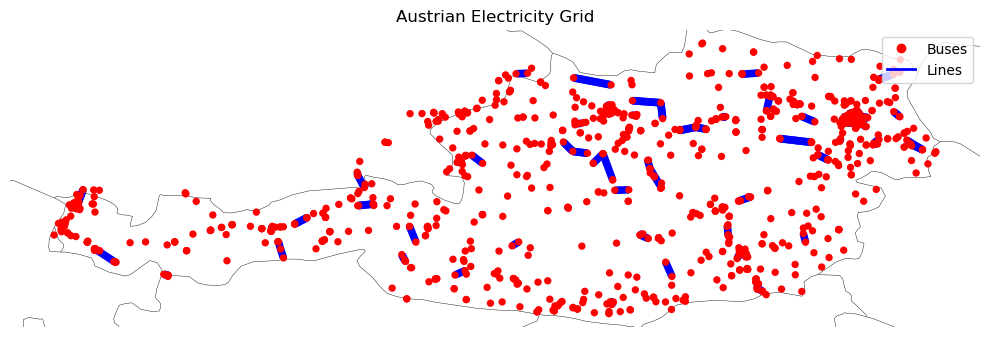

In [43]:
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


# Load the network
n = pypsa.Network('pypsa_csv')

# Plot the network
# Create a figure with GeoAxes using PlateCarree projection (standard lat/lon)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

n.plot(
    ax=ax,
    line_widths=5.5,
    bus_sizes=.001,
    line_colors="blue",
    bus_colors="red",
    title="Austrian Electricity Grid",
)

# Add legend manually
legend_elements = [
    plt.Line2D([0], [0], color='red', marker='o', linestyle='None', label='Buses'),
    plt.Line2D([0], [0], color='blue', lw=2, label='Lines'),
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x7b52bb39ce60>,
 <matplotlib.collections.LineCollection at 0x7b52bb63c5f0>)

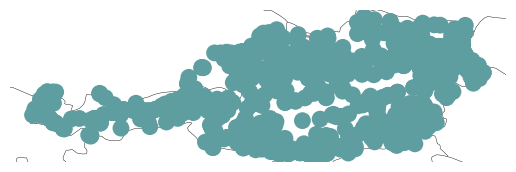

In [31]:
n.plot()

In [4]:
gdf_lines


,id,name,active,length,i_max,v_ref,r,x,c,comm,decomm,scenario,from_node,to_node,s_max,type,references,geometry
0,14001.0,182/1,1,5.360,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (13.03562 48.22073, 13.03565 48.219..."
1,14002.0,182/2,1,5.340,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (13.08025 48.25504, 13.07976 48.254..."
2,14003.0,182/7,1,6.220,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14003.0,14001.0,89.547027,None,None,"LINESTRING (13.03666 48.22089, 13.03764 48.220..."
3,14004.0,184/1,1,5.830,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14002.0,89.547027,None,None,"LINESTRING (13.07961 48.2557, 13.07874 48.2552..."
4,11030.0,127-9,1,16.189,470.0,110.0,0.2024,0.4329,6.0483,2024-01-01,2365/01/01,BGL,11002.0,11005.0,89.500000,None,None,"LINESTRING (16.89979 47.84484, 16.89925 47.845..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,20600.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20006.0,90000.0,0.000000,None,None,None
2032,20601.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20003.0,90000.0,0.000000,None,None,None
2033,20602.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20002.0,90000.0,0.000000,None,None,None
2034,31042.0,None,1,0.100,0.0,380.0,0.0000,0.0000,0.0000,2024-01-01,2100/01/01,BGL,31027.0,31020.0,0.000000,None,None,"LINESTRING (16.27613 47.25097, 16.27541 47.25005)"


In [5]:
gdf_buses

,id,name,v_ref,grid_level,comm,decomm,type,geometry
0,19001.0,Simmering,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.43448 48.18282)
1,39001.0,Simmering,380.0,2.0,2024-01-01,2100-01-01,1.0,POINT (16.43448 48.18282)
2,19002.0,Kaiserebersdorf,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.47564 48.15603)
3,13001.0,Schwechat,110.0,3.0,2024-01-01,2100-01-01,5.0,POINT (16.50701 48.13596)
4,19003.0,Wien Suedost,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.4203 48.12389)
...,...,...,...,...,...,...,...,...
915,14041.0,Sattledt,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (14.05211 48.08325)
916,14043.0,Pyhrn,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (14.33004 47.67829)
917,24141.0,Molln,220.0,2.0,2034-01-01,2100-01-01,1.0,POINT (14.24702 47.90342)
918,14141.0,Molln,30.0,4.0,2034-01-01,2100-01-01,1.0,POINT (14.24702 47.90342)
